# MLB Pitcher Cy Young Predictor - Modeling

## Section 0: Setup & Load data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load master dataset
master = pd.read_csv('../Data/Processed/master_dataset.csv')
print('Master dataset shape:', master.shape)

# Define feature sets
linear_features = ['SIERA', 'WAR', 'LOB%', 'W', 'L']

tree_features = ['xERA', 'SIERA', 'WAR', 'K%', 'HR/9', 'BB%', 
                 'K-BB%', 'K/BB', 'WHIP', 'BABIP', 'LOB%',
                 'ERA-', 'FIP-', 'IP', 'W', 'L']

arsenal_features = [
    'FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%',
    'vFA', 'vSI', 'vFC', 'vSL', 'vCU', 'vCH', 'vFS', 'vKC',
    'FA-X', 'SI-X', 'FC-X', 'SL-X', 'CU-X', 'CH-X', 'FS-X', 'KC-X',
    'FA-Z', 'SI-Z', 'FC-Z', 'SL-Z', 'CU-Z', 'CH-Z', 'FS-Z', 'KC-Z',
    'FA-SPN', 'SI-SPN', 'FC-SPN', 'SL-SPN', 'CU-SPN', 'CH-SPN', 'FS-SPN', 'KC-SPN',
]

print('Linear features:', len(linear_features))
print('Tree features:', len(tree_features))
print('Arsenal features:', len(arsenal_features))

Master dataset shape: (1866, 96)
Linear features: 5
Tree features: 16
Arsenal features: 40


## Section 1: Unsupervised Clustering (Pitcher archetypes)

### 1.1 Data preparation for clustering

In [12]:
# Section 2.1 - Data Preparation for Clustering
# Only require pitch usage % columns to be non-null
pct_cols = ['FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%']

arsenal_df = master[['Season', 'Name', 'Team'] + arsenal_features].dropna(subset=pct_cols)

print(f'Total pitchers: {len(master)}')
print(f'Pitchers with complete arsenal data: {len(arsenal_df)}')
print(f'Dropped: {len(master) - len(arsenal_df)}')
print()
print(f'Remaining nulls in arsenal features:')
print(arsenal_df[arsenal_features].isnull().sum().sort_values(ascending=False).head(10))

Total pitchers: 1866
Pitchers with complete arsenal data: 1860
Dropped: 6

Remaining nulls in arsenal features:
vFS       1619
FS-SPN    1619
FS-Z      1619
FS-X      1619
KC-SPN    1527
KC-Z      1526
KC-X      1526
vKC       1526
FC-SPN    1037
FC-Z      1037
dtype: int64


In [13]:
# Fill NaN with 0 for velocity, movement, spin of pitches not thrown
# This is valid because 0 usage % means the pitch doesn't exist for that pitcher
arsenal_df_filled = arsenal_df.copy()
arsenal_df_filled[arsenal_features] = arsenal_df_filled[arsenal_features].fillna(0)

# Verify no nulls remain
print('Remaining nulls:', arsenal_df_filled[arsenal_features].isnull().sum().sum())
print('Shape:', arsenal_df_filled.shape)

Remaining nulls: 0
Shape: (1860, 43)


### 1.2 PCA (Dimenstionality Reduction)

Scaled data shape: (1860, 40)


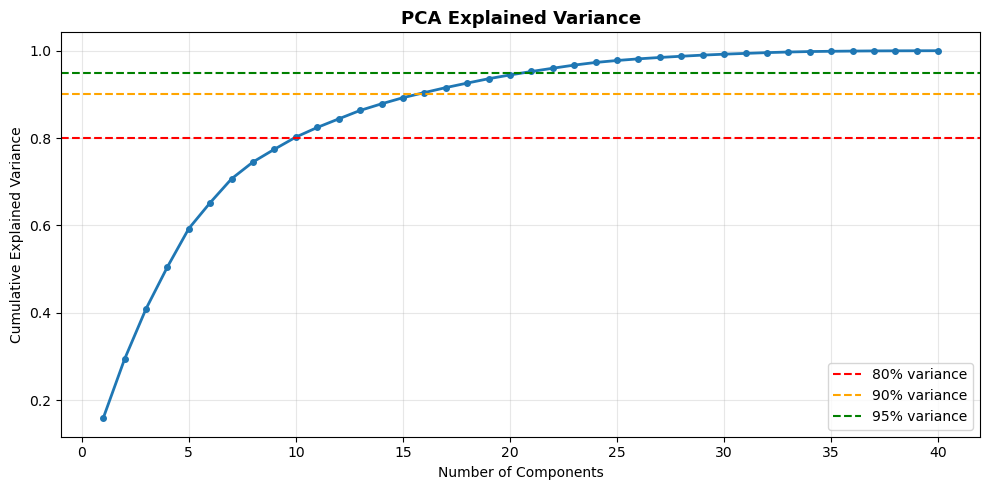

Components for 80% variance: 10
Components for 90% variance: 16
Components for 95% variance: 21


In [14]:
# Section 2.2 - PCA (Dimensionality Reduction)

# Standardize features - important for PCA since features are on different scales
# (velocity in mph, spin in rpm, usage in %, movement in inches)
X = arsenal_df_filled[arsenal_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled data shape:', X_scaled.shape)

# First run PCA with all components to see explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Plot explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4, linewidth=2)
plt.axhline(0.80, color='red', linestyle='--', label='80% variance')
plt.axhline(0.90, color='orange', linestyle='--', label='90% variance')
plt.axhline(0.95, color='green', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Components for 80% variance: {np.argmax(cumvar >= 0.80) + 1}')
print(f'Components for 90% variance: {np.argmax(cumvar >= 0.90) + 1}')
print(f'Components for 95% variance: {np.argmax(cumvar >= 0.95) + 1}')

####  Fit PCA with chosen components

In [17]:
# Section 2.2 continued - Fit PCA with chosen components
# 2D for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

# 10D for clustering (80% variance)
pca_10d = PCA(n_components=10)
X_10d = pca_10d.fit_transform(X_scaled)

print(f'2D PCA shape: {X_2d.shape}')
print(f'10D PCA shape: {X_10d.shape}')
print(f'PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total 2D variance: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%')
print(f'Total 10D variance: {sum(pca_10d.explained_variance_ratio_)*100:.1f}%')

2D PCA shape: (1860, 2)
10D PCA shape: (1860, 10)
PC1 explains: 15.8%
PC2 explains: 13.6%
Total 2D variance: 29.4%
Total 10D variance: 80.2%


In [25]:
# Summary of all 10 PCA components
pca_summary = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(10)],
    'Explained Variance %': (pca_10d.explained_variance_ratio_ * 100).round(1),
    'Cumulative %': (np.cumsum(pca_10d.explained_variance_ratio_) * 100).round(1)
})

print(pca_summary.to_string(index=False))

Component  Explained Variance %  Cumulative %
      PC1                  15.8          15.8
      PC2                  13.6          29.4
      PC3                  11.5          40.9
      PC4                   9.6          50.5
      PC5                   8.8          59.3
      PC6                   5.9          65.2
      PC7                   5.5          70.7
      PC8                   3.8          74.5
      PC9                   2.9          77.4
     PC10                   2.8          80.2


#### Elbow Method + Silhouette Score:

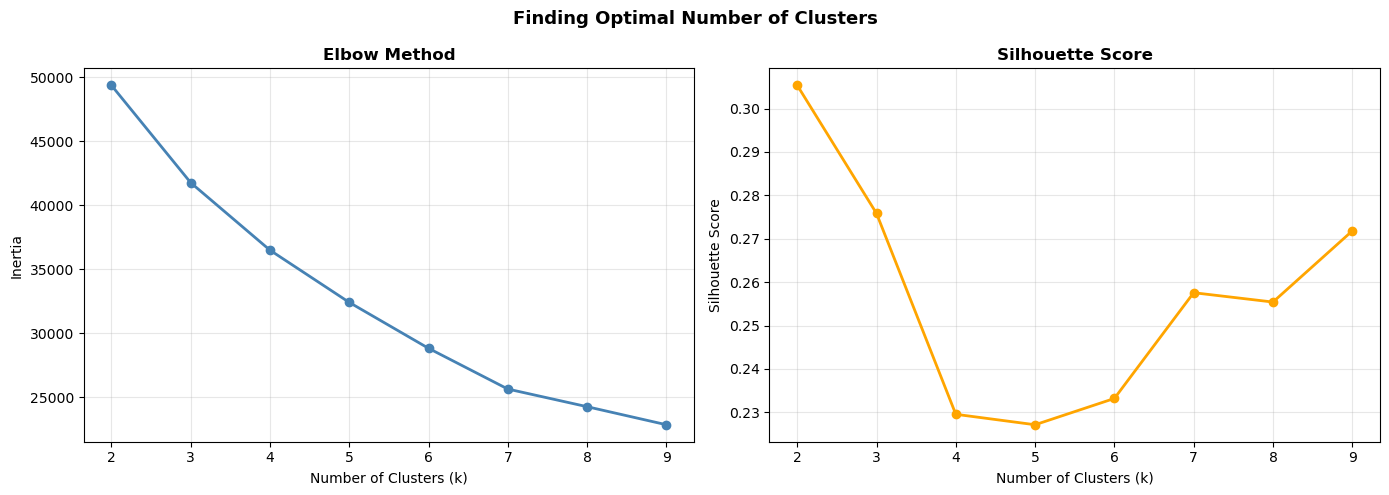

Best k by silhouette score: 2

k=2: silhouette=0.3053
k=3: silhouette=0.2758
k=4: silhouette=0.2296
k=5: silhouette=0.2271
k=6: silhouette=0.2332
k=7: silhouette=0.2576
k=8: silhouette=0.2554
k=9: silhouette=0.2718


In [18]:
#Find Optimal K

inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_10d)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_10d, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, color='orange')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.suptitle('Finding Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f'Best k by silhouette score: {best_k}')
print()
for k, s in zip(K_range, silhouette_scores):
    print(f'k={k}: silhouette={s:.4f}')

#### Kmeans clustering with k=4

In [19]:
# Section 2.4 - KMeans Clustering with k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_10d)

# Add cluster labels to dataframe
arsenal_df_filled['Cluster'] = clusters

print('Cluster sizes:')
print(arsenal_df_filled['Cluster'].value_counts().sort_index())
print()

# Look at mean arsenal characteristics per cluster
pitch_pct_cols = ['FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%']
vel_cols = ['vFA', 'vSI', 'vFC', 'vSL', 'vCU', 'vCH', 'vFS', 'vKC']

print('Mean pitch usage % per cluster:')
print(arsenal_df_filled.groupby('Cluster')[pitch_pct_cols].mean().round(3).to_string())
print()
print('Mean velocity per cluster:')
print(arsenal_df_filled.groupby('Cluster')[vel_cols].mean().round(1).to_string())

Cluster sizes:
Cluster
0    449
1    267
2    922
3    222
Name: count, dtype: int64

Mean pitch usage % per cluster:
           FA%    SI%    FC%    SL%    CU%    CH%    FS%    KC%
Cluster                                                        
0        0.340  0.166  0.076  0.136  0.109  0.162  0.002  0.002
1        0.337  0.169  0.061  0.143  0.012  0.107  0.001  0.169
2        0.337  0.184  0.063  0.172  0.110  0.130  0.001  0.000
3        0.320  0.165  0.081  0.158  0.082  0.015  0.164  0.017

Mean velocity per cluster:
          vFA   vSI   vFC   vSL   vCU   vCH   vFS   vKC
Cluster                                                
0        87.4  70.5  37.4  62.6  59.0  82.8   1.1   3.2
1        89.5  77.6  43.1  62.2   8.5  82.5   2.3  79.6
2        90.7  75.9  35.3  69.9  66.2  83.9   0.5   0.7
3        92.6  74.1  53.3  74.0  55.7  21.6  85.8  13.5


#### Archetype Labeling & Visualization

In [20]:

# Label archetypes based on cluster characteristics
archetype_labels = {
    0: 'Finesse/Soft Tosser',
    1: 'Knuckle Curve Specialist', 
    2: 'Standard Power Starter',
    3: 'Power Splitter/Cutter Arm'
}

arsenal_df_filled['Archetype'] = arsenal_df_filled['Cluster'].map(archetype_labels)

# Add 2D PCA coordinates for visualization
arsenal_df_filled['PC1'] = X_2d[:, 0]
arsenal_df_filled['PC2'] = X_2d[:, 1]

# Add Cy Young info
arsenal_df_filled = arsenal_df_filled.merge(
    master[['Season', 'Name', 'CY_winner', 'Share']],
    on=['Season', 'Name'], how='left'
)

winners = arsenal_df_filled[arsenal_df_filled['CY_winner'] == 1]

print('Archetype distribution:')
print(arsenal_df_filled['Archetype'].value_counts())
print()
print('Cy Young winners per archetype:')
print(winners['Archetype'].value_counts())

Archetype distribution:
Archetype
Standard Power Starter       922
Finesse/Soft Tosser          449
Knuckle Curve Specialist     267
Power Splitter/Cutter Arm    222
Name: count, dtype: int64

Cy Young winners per archetype:
Archetype
Standard Power Starter       11
Finesse/Soft Tosser           5
Knuckle Curve Specialist      5
Power Splitter/Cutter Arm     1
Name: count, dtype: int64


## Section 2: Regression (Vote Share Prediction)

### Data Preparation

In [26]:
# Section 3 - Regression (Vote Share Prediction)
# 3.1 - Data Preparation

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Only use pitchers who received Cy Young votes
cy_df = master[master['Share'] > 0].copy()
print(f'Cy Young voters: {len(cy_df)}')
print(f'Target variable (Share) stats:')
print(cy_df['Share'].describe().round(3))

Cy Young voters: 184
Target variable (Share) stats:
count    184.000
mean       0.287
std        0.300
min        0.010
25%        0.040
50%        0.190
75%        0.412
max        1.000
Name: Share, dtype: float64


In [28]:
# Fix LOB% string formatting
master['LOB%'] = pd.to_numeric(master['LOB%'].astype(str).str.replace('%', ''), errors='coerce') / 100

# Recreate cy_df after fix
cy_df = master[master['Share'] > 0].copy()

# Verify
print(master['LOB%'].dtype)
print(master['LOB%'].head(3))

float64
0    0.007277
1    0.007377
2    0.006931
Name: LOB%, dtype: float64


### Feature sets and train/test split

In [29]:
# 3.2 - Prepare feature sets and train/test split
from sklearn.model_selection import train_test_split

# Drop any rows with nulls in feature columns
linear_df = cy_df[linear_features + ['Share']].dropna()
tree_df = cy_df[tree_features + ['Share']].dropna()

print(f'Linear model dataset: {len(linear_df)} rows, {len(linear_features)} features')
print(f'Tree model dataset: {len(tree_df)} rows, {len(tree_features)} features')

# Linear features
X_linear = linear_df[linear_features]
y_linear = linear_df['Share']

# Tree features
X_tree = tree_df[tree_features]
y_tree = tree_df['Share']

# Train/test split (80/20)
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42)

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42)

# Scale features for linear models
scaler = StandardScaler()
X_lin_train_scaled = scaler.fit_transform(X_lin_train)
X_lin_test_scaled = scaler.transform(X_lin_test)

print()
print(f'Linear train: {len(X_lin_train)} | test: {len(X_lin_test)}')
print(f'Tree train: {len(X_tree_train)} | test: {len(X_tree_test)}')

Linear model dataset: 184 rows, 5 features
Tree model dataset: 184 rows, 16 features

Linear train: 147 | test: 37
Tree train: 147 | test: 37


In [30]:
# 3.3 - Train and evaluate all regression models
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_lin_train_scaled, y_lin_train)
y_pred_lr = lr.predict(X_lin_test_scaled)
cv_lr = cross_val_score(lr, X_lin_train_scaled, y_lin_train, cv=kf, scoring='r2')
results['Linear Regression'] = {
    'R2': r2_score(y_lin_test, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_lin_test, y_pred_lr)),
    'CV R2 Mean': cv_lr.mean(),
    'CV R2 Std': cv_lr.std()
}

# 2. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_lin_train_scaled, y_lin_train)
y_pred_ridge = ridge.predict(X_lin_test_scaled)
cv_ridge = cross_val_score(ridge, X_lin_train_scaled, y_lin_train, cv=kf, scoring='r2')
results['Ridge'] = {
    'R2': r2_score(y_lin_test, y_pred_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_lin_test, y_pred_ridge)),
    'CV R2 Mean': cv_ridge.mean(),
    'CV R2 Std': cv_ridge.std()
}

# 3. Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_lin_train_scaled, y_lin_train)
y_pred_lasso = lasso.predict(X_lin_test_scaled)
cv_lasso = cross_val_score(lasso, X_lin_train_scaled, y_lin_train, cv=kf, scoring='r2')
results['Lasso'] = {
    'R2': r2_score(y_lin_test, y_pred_lasso),
    'RMSE': np.sqrt(mean_squared_error(y_lin_test, y_pred_lasso)),
    'CV R2 Mean': cv_lasso.mean(),
    'CV R2 Std': cv_lasso.std()
}

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_tree_train, y_tree_train)
y_pred_rf = rf.predict(X_tree_test)
cv_rf = cross_val_score(rf, X_tree_train, y_tree_train, cv=kf, scoring='r2')
results['Random Forest'] = {
    'R2': r2_score(y_tree_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_tree_test, y_pred_rf)),
    'CV R2 Mean': cv_rf.mean(),
    'CV R2 Std': cv_rf.std()
}

# 5. XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_tree_train, y_tree_train)
y_pred_xgb = xgb.predict(X_tree_test)
cv_xgb = cross_val_score(xgb, X_tree_train, y_tree_train, cv=kf, scoring='r2')
results['XGBoost'] = {
    'R2': r2_score(y_tree_test, y_pred_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_tree_test, y_pred_xgb)),
    'CV R2 Mean': cv_xgb.mean(),
    'CV R2 Std': cv_xgb.std()
}

# Display results
results_df = pd.DataFrame(results).T.round(3)
print('Regression Model Comparison:')
print(results_df.to_string())

Regression Model Comparison:
                      R2   RMSE  CV R2 Mean  CV R2 Std
Linear Regression  0.399  0.223       0.253      0.160
Ridge              0.401  0.222       0.253      0.158
Lasso              0.426  0.218       0.250      0.161
Random Forest      0.534  0.196       0.376      0.239
XGBoost            0.416  0.220       0.210      0.363


### Hyperparameter Tuning

In [32]:
# Section 3.4 - Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Tune Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=0)

rf_grid.fit(X_tree_train, y_tree_train)

print('Best RF parameters:', rf_grid.best_params_)
print('Best RF CV R2:', rf_grid.best_score_.round(3))

# Evaluate on test set
y_pred_rf_tuned = rf_grid.predict(X_tree_test)
print('Tuned RF Test R2:', round(r2_score(y_tree_test, y_pred_rf_tuned), 3))
print('Tuned RF Test RMSE:', round(np.sqrt(mean_squared_error(y_tree_test, y_pred_rf_tuned)), 3))

Best RF parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV R2: 0.419
Tuned RF Test R2: 0.534
Tuned RF Test RMSE: 0.196


In [33]:
# Tune XGBoost
from xgboost import XGBRegressor

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params, cv=5, scoring='r2', n_jobs=-1, verbose=0)

xgb_grid.fit(X_tree_train, y_tree_train)

print('Best XGB parameters:', xgb_grid.best_params_)
print('Best XGB CV R2:', round(xgb_grid.best_score_, 3))

# Evaluate on test set
y_pred_xgb_tuned = xgb_grid.predict(X_tree_test)
print('Tuned XGB Test R2:', round(r2_score(y_tree_test, y_pred_xgb_tuned), 3))
print('Tuned XGB Test RMSE:', round(np.sqrt(mean_squared_error(y_tree_test, y_pred_xgb_tuned)), 3))

Best XGB parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best XGB CV R2: 0.407
Tuned XGB Test R2: 0.606
Tuned XGB Test RMSE: 0.18


### Final Regression Results Summary

In [34]:
# Final Regression Results Summary
results_final = {
    'Linear Regression': {'Test R2': 0.399, 'Test RMSE': 0.223, 'CV R2': 0.253, 'CV Std': 0.160},
    'Ridge': {'Test R2': 0.401, 'Test RMSE': 0.222, 'CV R2': 0.253, 'CV Std': 0.158},
    'Lasso': {'Test R2': 0.426, 'Test RMSE': 0.218, 'CV R2': 0.250, 'CV Std': 0.161},
    'Random Forest': {'Test R2': 0.534, 'Test RMSE': 0.196, 'CV R2': 0.376, 'CV Std': 0.239},
    'XGBoost (Tuned)': {'Test R2': 0.606, 'Test RMSE': 0.180, 'CV R2': 0.407, 'CV Std': 0.363}
}

results_final_df = pd.DataFrame(results_final).T
results_final_df.index.name = 'Model'

print('='*65)
print('REGRESSION MODEL COMPARISON — Vote Share Prediction')
print('='*65)
print(results_final_df.round(3).to_string())
print('='*65)
print('Best Model: XGBoost (Tuned) — Test R2: 0.606, RMSE: 0.180')
print('='*65)

REGRESSION MODEL COMPARISON — Vote Share Prediction
                   Test R2  Test RMSE  CV R2  CV Std
Model                                               
Linear Regression    0.399      0.223  0.253   0.160
Ridge                0.401      0.222  0.253   0.158
Lasso                0.426      0.218  0.250   0.161
Random Forest        0.534      0.196  0.376   0.239
XGBoost (Tuned)      0.606      0.180  0.407   0.363
Best Model: XGBoost (Tuned) — Test R2: 0.606, RMSE: 0.180


### Actual vs predicted Vote share

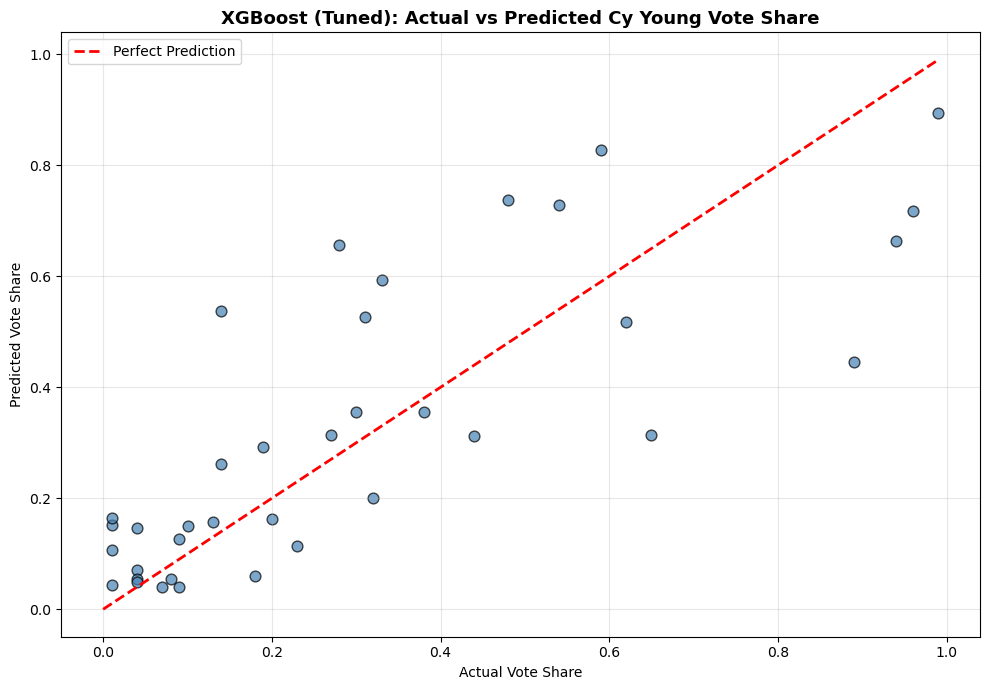

In [36]:
# Actual vs Predicted Vote Share - Best Model (XGBoost)
y_pred_xgb_tuned = xgb_grid.predict(X_tree_test)

plt.figure(figsize=(10, 7))
plt.scatter(y_tree_test, y_pred_xgb_tuned, 
            alpha=0.7, color='steelblue', edgecolors='black', s=60)

# Perfect prediction line
max_val = max(y_tree_test.max(), y_pred_xgb_tuned.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Vote Share')
plt.ylabel('Predicted Vote Share')
plt.title('XGBoost (Tuned): Actual vs Predicted Cy Young Vote Share', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Classification (Cy young Winner Prediction)

#### Data Preperation

In [37]:
# Classification (Cy Young Winner Prediction)
# 4.1 - Data Preparation

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

# Use all pitchers for classification (not just voters)
# Target: CY_winner (1 = winner, 0 = not winner)
print('Class distribution:')
print(master['CY_winner'].value_counts())
print(f'Class imbalance ratio: {(master["CY_winner"]==0).sum()}/{master["CY_winner"].sum()} = {(master["CY_winner"]==0).sum()/master["CY_winner"].sum():.0f}:1')

# Prepare datasets
linear_clf_df = master[linear_features + ['CY_winner']].dropna()
tree_clf_df = master[tree_features + ['CY_winner']].dropna()

X_lin_clf = linear_clf_df[linear_features]
y_lin_clf = linear_clf_df['CY_winner']

X_tree_clf = tree_clf_df[tree_features]
y_tree_clf = tree_clf_df['CY_winner']

# Train/test split
X_lin_clf_train, X_lin_clf_test, y_lin_clf_train, y_lin_clf_test = train_test_split(
    X_lin_clf, y_lin_clf, test_size=0.2, random_state=42, stratify=y_lin_clf)

X_tree_clf_train, X_tree_clf_test, y_tree_clf_train, y_tree_clf_test = train_test_split(
    X_tree_clf, y_tree_clf, test_size=0.2, random_state=42, stratify=y_lin_clf)

# Scale for logistic regression
X_lin_clf_train_scaled = scaler.fit_transform(X_lin_clf_train)
X_lin_clf_test_scaled = scaler.transform(X_lin_clf_test)

print(f'\nLinear train: {len(X_lin_clf_train)} | test: {len(X_lin_clf_test)}')
print(f'Tree train: {len(X_tree_clf_train)} | test: {len(X_tree_clf_test)}')
print(f'Winners in test set: {y_lin_clf_test.sum()}')

Class distribution:
CY_winner
0    1844
1      22
Name: count, dtype: int64
Class imbalance ratio: 1844/22 = 84:1

Linear train: 1492 | test: 374
Tree train: 1492 | test: 374
Winners in test set: 4


### Train Classification Modles

In [38]:
# 4.2 - Train Classification Models
clf_results = {}

# 1. Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_lin_clf_train_scaled, y_lin_clf_train)
y_pred_lr_clf = log_reg.predict(X_lin_clf_test_scaled)
y_prob_lr_clf = log_reg.predict_proba(X_lin_clf_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_lin_clf_test, y_pred_lr_clf, target_names=['Not Winner', 'Winner']))
print(f'ROC-AUC: {roc_auc_score(y_lin_clf_test, y_prob_lr_clf):.3f}')

# 2. Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_clf.fit(X_tree_clf_train, y_tree_clf_train)
y_pred_rf_clf = rf_clf.predict(X_tree_clf_test)
y_prob_rf_clf = rf_clf.predict_proba(X_tree_clf_test)[:, 1]

print('\n=== Random Forest ===')
print(classification_report(y_tree_clf_test, y_pred_rf_clf, target_names=['Not Winner', 'Winner']))
print(f'ROC-AUC: {roc_auc_score(y_tree_clf_test, y_prob_rf_clf):.3f}')

# 3. XGBoost Classifier
scale_pos_weight = (y_tree_clf_train == 0).sum() / (y_tree_clf_train == 1).sum()
xgb_clf = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, 
                          random_state=42, verbosity=0)
xgb_clf.fit(X_tree_clf_train, y_tree_clf_train)
y_pred_xgb_clf = xgb_clf.predict(X_tree_clf_test)
y_prob_xgb_clf = xgb_clf.predict_proba(X_tree_clf_test)[:, 1]

print('\n=== XGBoost ===')
print(classification_report(y_tree_clf_test, y_pred_xgb_clf, target_names=['Not Winner', 'Winner']))
print(f'ROC-AUC: {roc_auc_score(y_tree_clf_test, y_prob_xgb_clf):.3f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

  Not Winner       1.00      0.90      0.95       370
      Winner       0.10      1.00      0.18         4

    accuracy                           0.90       374
   macro avg       0.55      0.95      0.56       374
weighted avg       0.99      0.90      0.94       374

ROC-AUC: 0.984

=== Random Forest ===
              precision    recall  f1-score   support

  Not Winner       0.99      0.99      0.99       370
      Winner       0.50      0.50      0.50         4

    accuracy                           0.99       374
   macro avg       0.75      0.75      0.75       374
weighted avg       0.99      0.99      0.99       374

ROC-AUC: 0.961

=== XGBoost ===
              precision    recall  f1-score   support

  Not Winner       0.99      0.99      0.99       370
      Winner       0.50      0.50      0.50         4

    accuracy                           0.99       374
   macro avg       0.75      0

What This Tells Us
* Logistic Regression finds every winner but cries wolf too much — 36 false alarms for 4 correct winners. Good for "don't miss any winners" use case.
* Random Forest and XGBoost are more selective — when they call someone a winner they're right 50% of the time, but they miss half the actual winners.
* ROC-AUC is most important here — all three models are excellent at ranking winners above non-winners (0.96-0.98). This means the model correctly orders candidates even if the binary classification is imperfect.

Which model is best?

*For ranking candidates → Logistic Regression (ROC-AUC 0.984)
*For binary prediction → RF/XGBoost (better F1 for winners)

### Visualizations

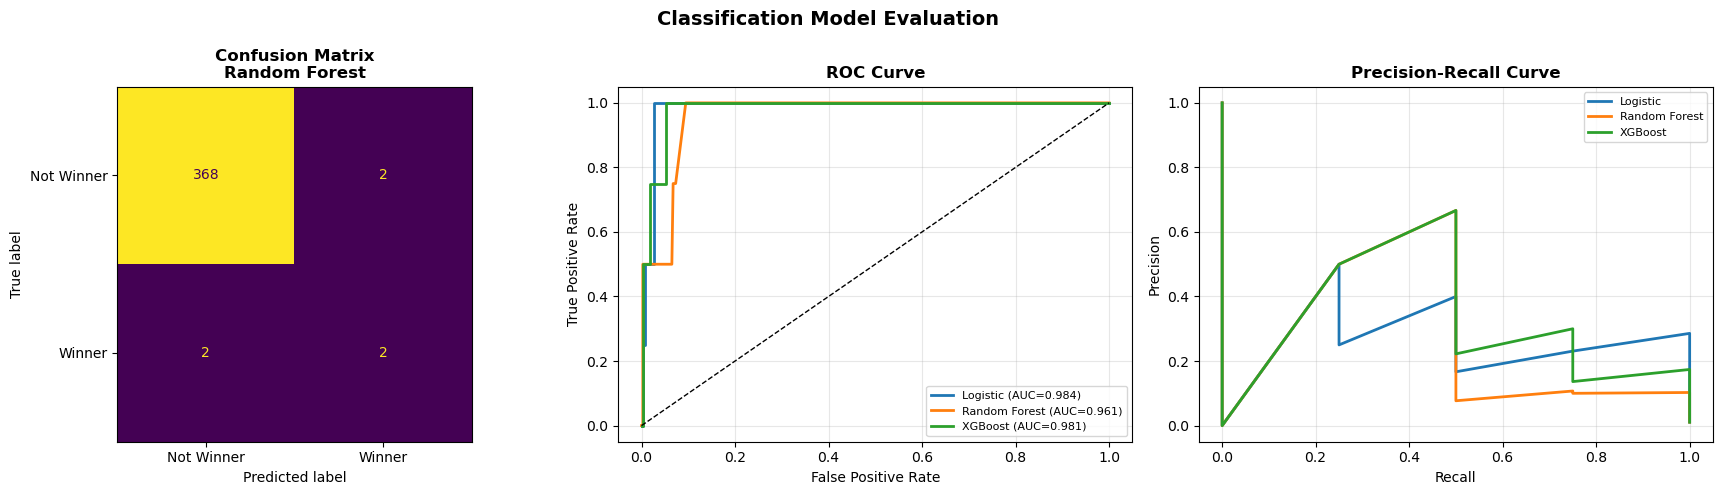

In [39]:
# Classification Visualizations
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix - Best model (Random Forest)
cm = confusion_matrix(y_tree_clf_test, y_pred_rf_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Not Winner', 'Winner'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix\nRandom Forest', fontweight='bold')

# 2. ROC Curve - All models
for name, y_prob in [('Logistic (AUC=0.984)', y_prob_lr_clf),
                      ('Random Forest (AUC=0.961)', y_prob_rf_clf),
                      ('XGBoost (AUC=0.981)', y_prob_xgb_clf)]:
    fpr, tpr, _ = roc_curve(y_tree_clf_test, y_prob)
    axes[1].plot(fpr, tpr, linewidth=2, label=name)

axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve - All models
for name, y_prob in [('Logistic', y_prob_lr_clf),
                      ('Random Forest', y_prob_rf_clf),
                      ('XGBoost', y_prob_xgb_clf)]:
    prec, rec, _ = precision_recall_curve(y_tree_clf_test, y_prob)
    axes[2].plot(rec, prec, linewidth=2, label=name)

axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('Classification Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/classification_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5: SHAP Analysis

In [41]:
import subprocess
subprocess.run(['pip', 'install', 'shap'])
import shap
print('shap installed successfully')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.3/562.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 22.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.


shap installed successfully


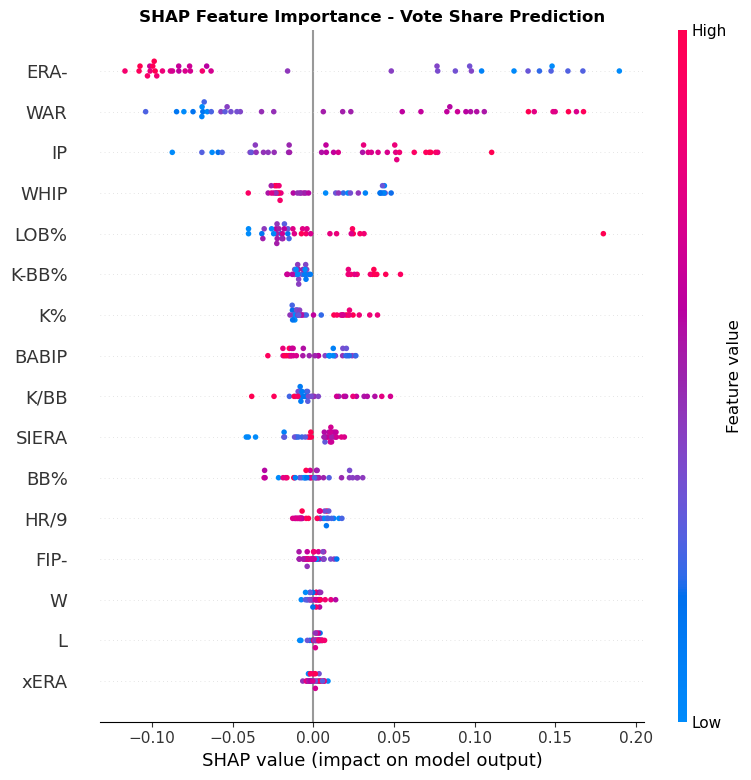

In [42]:
# Section 5 - SHAP Analysis
import shap

# Use best regression model (XGBoost) for SHAP
# SHAP tells us which features drive vote share predictions

explainer = shap.TreeExplainer(xgb_grid.best_estimator_)
shap_values = explainer.shap_values(X_tree_test)

# Summary plot - feature importance
plt.figure()
shap.summary_plot(shap_values, X_tree_test, 
                  feature_names=tree_features,
                  show=False)
plt.title('SHAP Feature Importance - Vote Share Prediction', 
          fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

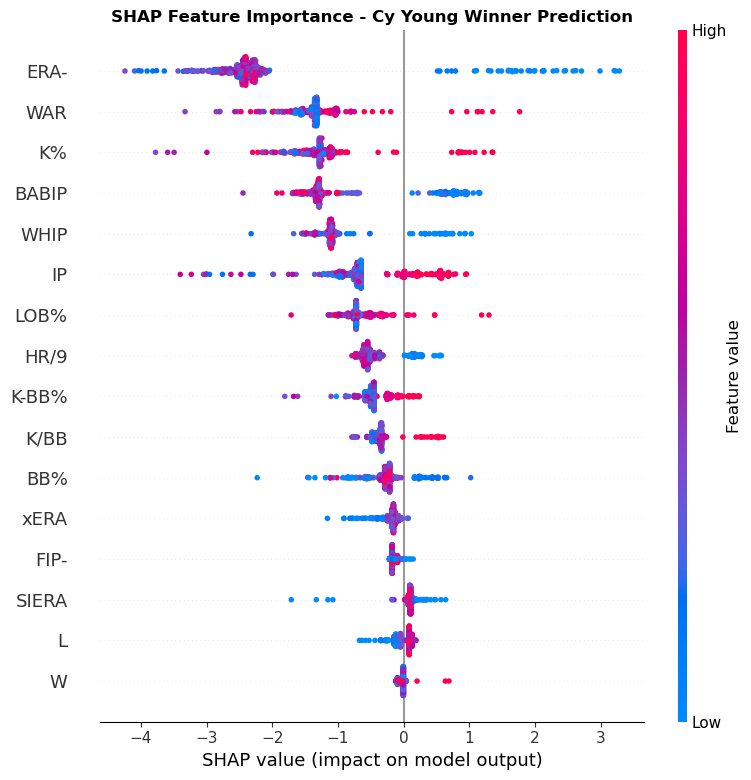

In [43]:
# SHAP for Classification Model (XGBoost Classifier)
explainer_clf = shap.TreeExplainer(xgb_clf)
shap_values_clf = explainer_clf.shap_values(X_tree_clf_test)

plt.figure()
shap.summary_plot(shap_values_clf, X_tree_clf_test,
                  feature_names=tree_features,
                  show=False)
plt.title('SHAP Feature Importance - Cy Young Winner Prediction',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/shap_summary_clf.png', dpi=150, bbox_inches='tight')
plt.show()

#### Bar charts of SHAP

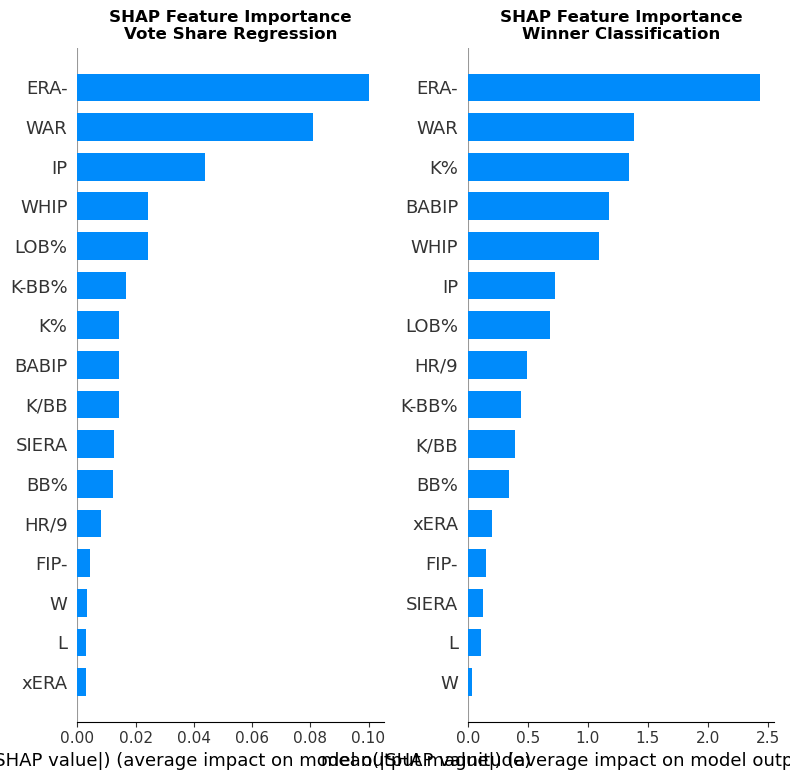

In [45]:
# SHAP Bar Charts - Regression and Classification side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Regression bar chart
plt.sca(axes[0])
shap.summary_plot(shap_values, X_tree_test,
                  feature_names=tree_features,
                  plot_type='bar',
                  show=False)
axes[0].set_title('SHAP Feature Importance\nVote Share Regression', fontweight='bold')

# Classification bar chart
plt.sca(axes[1])
shap.summary_plot(shap_values_clf, X_tree_clf_test,
                  feature_names=tree_features,
                  plot_type='bar',
                  show=False)
axes[1].set_title('SHAP Feature Importance\nWinner Classification', fontweight='bold')

plt.tight_layout()
plt.savefig('../Outputs/shap_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

## Historical Snub Analysis

In [46]:
# Historical Snubs Analysis
# Use XGBoost tuned model to predict vote share for all pitchers
# Compare model's top pick vs actual winner each season

# Prepare full dataset with tree features
full_df = master[['Season', 'Name', 'Team', 'League', 'CY_winner', 'Share'] + tree_features].dropna(subset=tree_features)

# Fix LOB% if needed
if full_df['LOB%'].dtype == object:
    full_df['LOB%'] = full_df['LOB%'].str.replace('%', '').astype(float) / 100

# Predict vote share for all pitchers
full_df = full_df.copy()
full_df['Predicted_Share'] = xgb_grid.predict(full_df[tree_features])

# For each season and league find actual winner and model's top pick
snub_results = []

for season in sorted(full_df['Season'].unique()):
    for league in ['AL', 'NL']:
        season_league = full_df[
            (full_df['Season'] == season) & 
            (full_df['League'] == league)
        ]
        
        if len(season_league) == 0:
            continue
            
        # Actual winner
        actual_winner = season_league[season_league['CY_winner'] == 1]
        if len(actual_winner) == 0:
            continue
        actual_name = actual_winner.iloc[0]['Name']
        actual_share = actual_winner.iloc[0]['Share']
        
        # Model's top pick
        model_pick = season_league.nlargest(1, 'Predicted_Share').iloc[0]
        model_name = model_pick['Name']
        model_pred = model_pick['Predicted_Share']
        
        # Is it a snub?
        is_snub = actual_name != model_name
        
        snub_results.append({
            'Season': season,
            'League': league,
            'Actual Winner': actual_name,
            'Actual Share': round(actual_share, 3),
            'Model Pick': model_name,
            'Model Pred Share': round(model_pred, 3),
            'Snub': '❌ YES' if is_snub else '✅ NO'
        })

snub_df = pd.DataFrame(snub_results)
print(snub_df.to_string(index=False))
print()
print(f'Total races: {len(snub_df)}')
print(f'Model agrees with voters: {(snub_df["Snub"] == "✅ NO").sum()}')
print(f'Potential snubs identified: {(snub_df["Snub"] == "❌ YES").sum()}')

 Season League    Actual Winner  Actual Share       Model Pick  Model Pred Share  Snub
   2015     AL   Dallas Keuchel          0.89      David Price             0.606 ❌ YES
   2015     NL     Jake Arrieta          0.80     Jake Arrieta             0.819  ✅ NO
   2016     AL    Rick Porcello          0.65 Justin Verlander             0.578 ❌ YES
   2016     NL     Max Scherzer          0.91     Max Scherzer             0.784  ✅ NO
   2017     AL     Corey Kluber          0.97     Corey Kluber             0.892  ✅ NO
   2017     NL     Max Scherzer          0.96     Max Scherzer             0.718  ✅ NO
   2018     AL      Blake Snell          0.80      Blake Snell             0.763  ✅ NO
   2018     NL     Jacob deGrom          0.99     Jacob deGrom             0.894  ✅ NO
   2019     AL Justin Verlander          0.81 Justin Verlander             0.828  ✅ NO
   2019     NL     Jacob deGrom          0.99     Jacob deGrom             0.934  ✅ NO
   2020     AL     Shane Bieber          1.

## Section 6: Overlap (PCA Archetypes plot + Cy Young Winners Overlay)

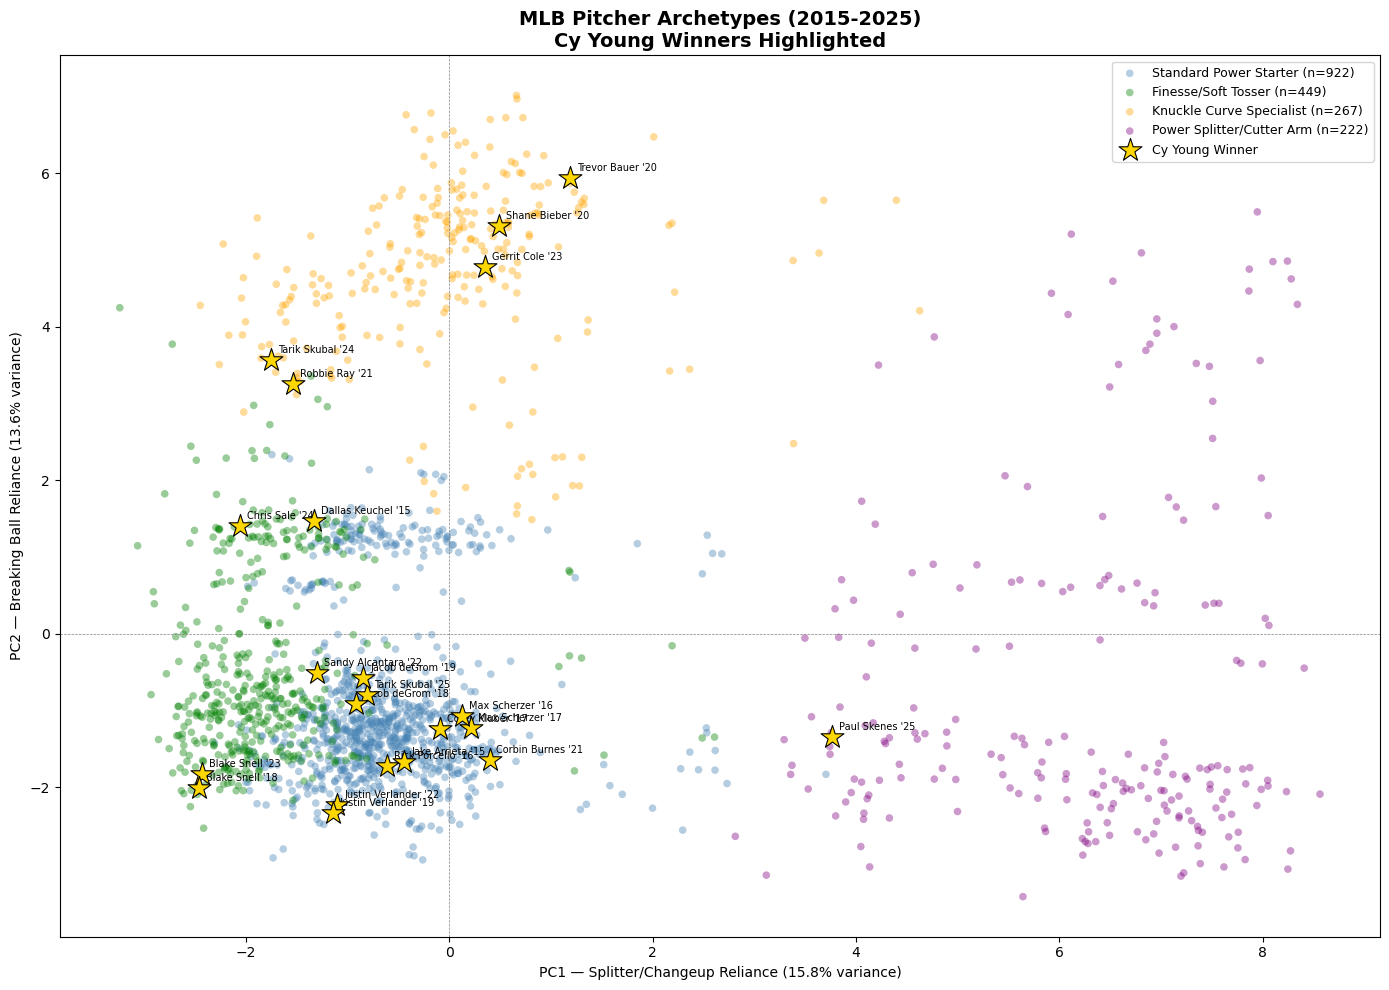

In [23]:
# Section 2.5 & 6 - PCA Archetype Plot with Cy Young Winners Overlay
colors = {
    'Standard Power Starter': 'steelblue',
    'Finesse/Soft Tosser': 'green',
    'Knuckle Curve Specialist': 'orange',
    'Power Splitter/Cutter Arm': 'purple'
}

fig, ax = plt.subplots(figsize=(14, 10))

# Plot all pitchers by archetype
for archetype, color in colors.items():
    subset = arsenal_df_filled[arsenal_df_filled['Archetype'] == archetype]
    ax.scatter(subset['PC1'], subset['PC2'],
               c=color, label=f'{archetype} (n={len(subset)})',
               alpha=0.4, s=30, edgecolors='none')

# Overlay Cy Young winners as gold stars
ax.scatter(winners['PC1'], winners['PC2'],
           c='gold', s=300, marker='*',
           edgecolors='black', linewidths=0.8,
           label='Cy Young Winner', zorder=5)

# Annotate winners
for _, row in winners.iterrows():
    ax.annotate(f"{row['Name']} '{str(int(row['Season']))[2:]}",
                (row['PC1'], row['PC2']),
                fontsize=7, xytext=(5, 5),
                textcoords='offset points')

ax.set_xlabel('PC1 — Splitter/Changeup Reliance (15.8% variance)')
ax.set_ylabel('PC2 — Breaking Ball Reliance (13.6% variance)')
ax.set_title('MLB Pitcher Archetypes (2015-2025)\nCy Young Winners Highlighted',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('../Outputs/archetype_plot.png', dpi=150, bbox_inches='tight')
plt.show()